In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.vgg16 import VGG16

In [2]:
vgg = VGG16(weights='imagenet')

In [3]:
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [4]:
# from tensorflow.keras.utils import plot_model

# plot_model(model, show_shapes=True)

In [5]:
for i in range(len(vgg.layers)):
    # check for convolutional layer
    if 'conv' not in vgg.layers[i].name:
        continue
    
    # get filter weights
    filters,biases = vgg.layers[i].get_weights()
    print("layer_number",i,vgg.layers[i].name,filters.shape) 

layer_number 1 block1_conv1 (3, 3, 3, 64)
layer_number 2 block1_conv2 (3, 3, 64, 64)
layer_number 4 block2_conv1 (3, 3, 64, 128)
layer_number 5 block2_conv2 (3, 3, 128, 128)
layer_number 7 block3_conv1 (3, 3, 128, 256)
layer_number 8 block3_conv2 (3, 3, 256, 256)
layer_number 9 block3_conv3 (3, 3, 256, 256)
layer_number 11 block4_conv1 (3, 3, 256, 512)
layer_number 12 block4_conv2 (3, 3, 512, 512)
layer_number 13 block4_conv3 (3, 3, 512, 512)
layer_number 15 block5_conv1 (3, 3, 512, 512)
layer_number 16 block5_conv2 (3, 3, 512, 512)
layer_number 17 block5_conv3 (3, 3, 512, 512)


In [6]:
# retrieve weights from the second hidden layer
filters , biases = vgg.layers[1].get_weights()

In [7]:
# normalize filter value to 0-1 so we can visualize them
f_min,f_max = filters.min(),filters.max()
filters = (filters-f_min)/(f_max-f_min)

In [22]:
from matplotlib import pyplot

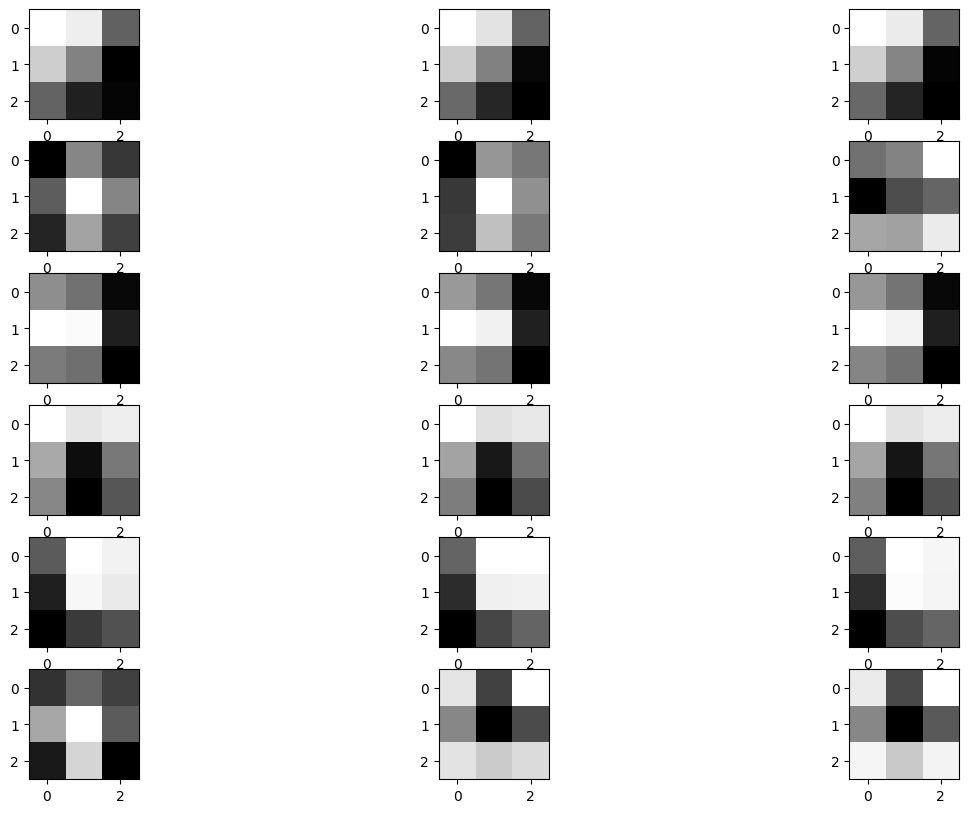

In [9]:
n_filters = 6
ix = 1
fig = pyplot.figure(figsize=(15,10))
for i in range(n_filters):
    # get the filters
    f = filters[:,:,:,i]
    for j in range(3):
        # subplot for 6 filters and 3 channels
        pyplot.subplot(n_filters,3,ix)
        pyplot.imshow(f[:,:,j],cmap='gray')
        ix += 1
        
# plot the filters
pyplot.show()
        

In [24]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input
from numpy import expand_dims

In [25]:
feature_model = Model(
    inputs=vgg.input,
    outputs=vgg.layers[1].output
)

In [26]:
image = load_img('sk.jpg',target_size=(224,224))

# convert the image to an array
image = img_to_array(image)

# expand dimensions so that it represents a single 'sample'
image = expand_dims(image,axis=0)

image = preprocess_input(image)

1/1 [==============================] - 0s 37ms/step


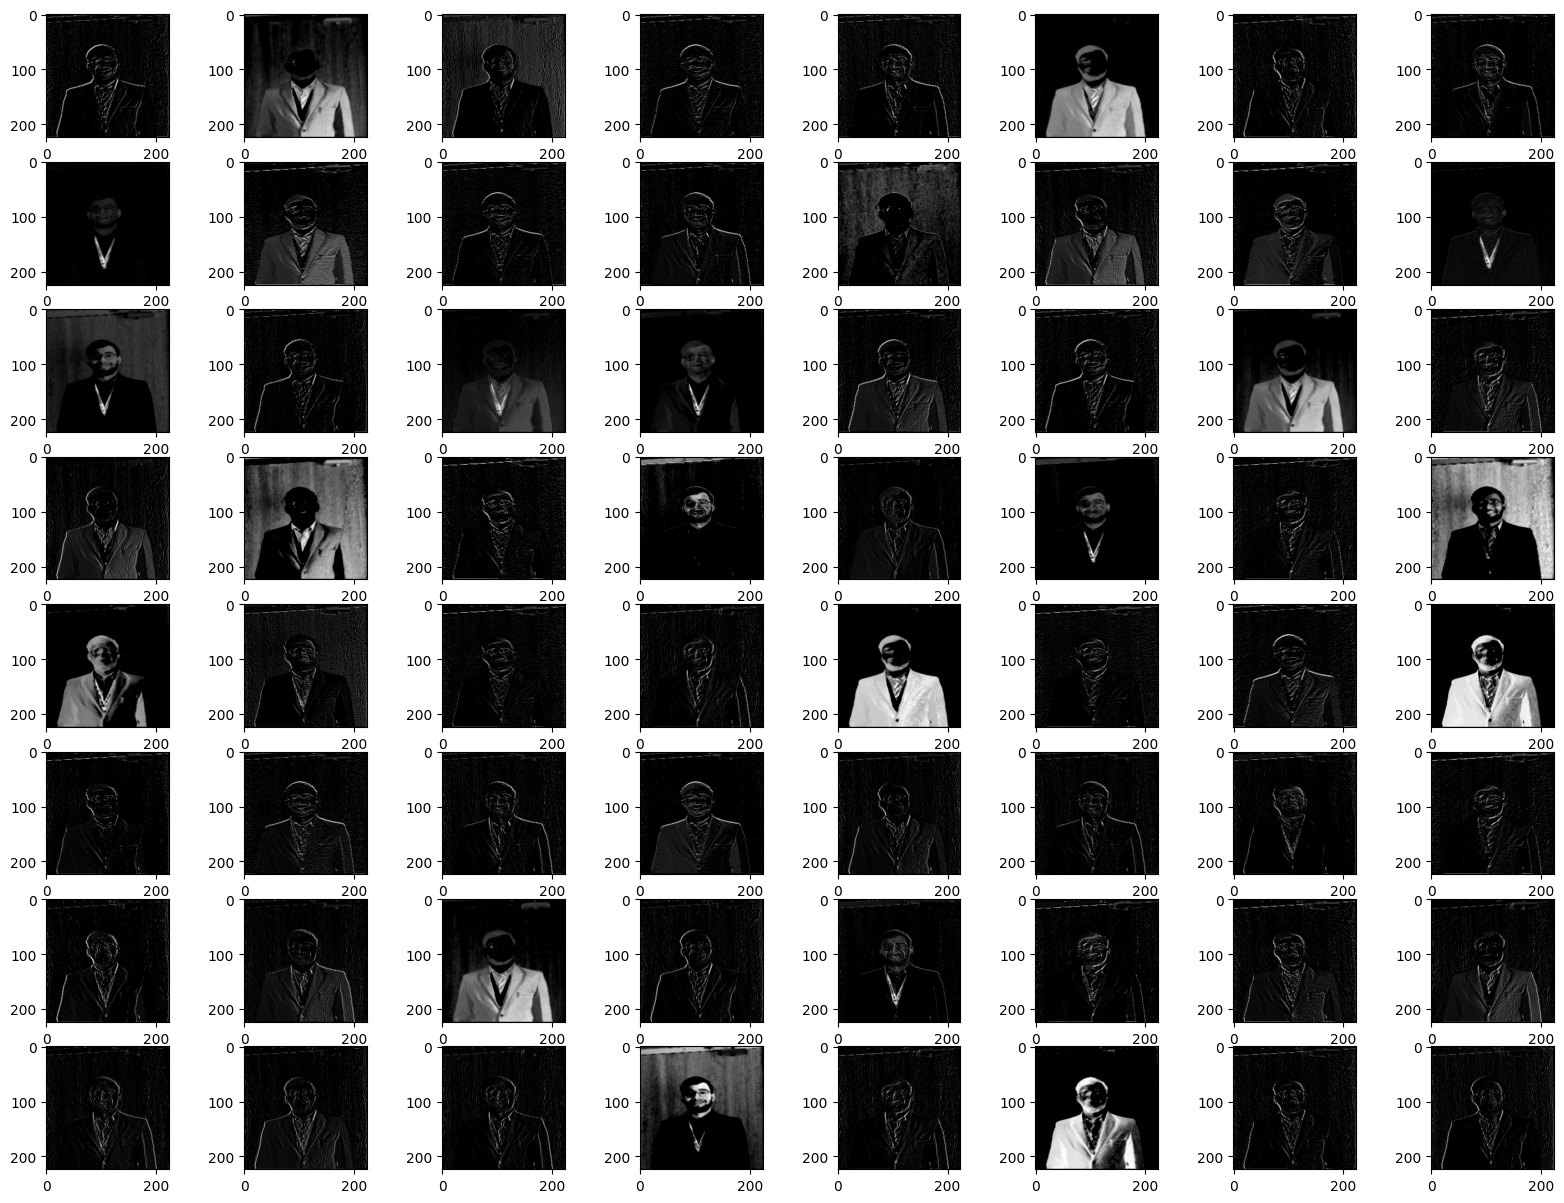

In [27]:
# calculating feature map
features = feature_model.predict(image)

fig = pyplot.figure(figsize=(20,15))
for i in range(1,features.shape[3]+1):
    pyplot.subplot(8,8,i)
    pyplot.imshow(features[0,:,:,i-1],cmap='gray')
    
pyplot.show()

In [28]:
model2 = VGG16()

In [29]:
layer_index = [2,5,9,13,17]
outputs = [model2.layers[i+1].output for i in layer_index]

model3 = Model(inputs=model2.inputs , outputs = outputs)

In [30]:
model3.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

1/1 [==============================] - 0s 86ms/step


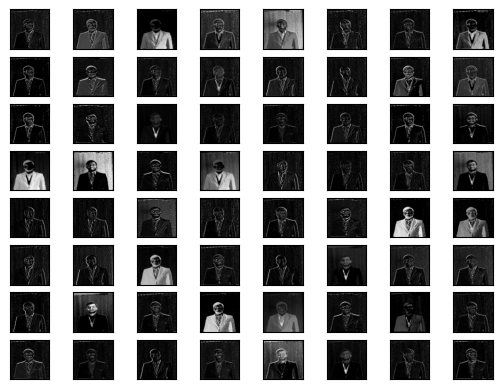

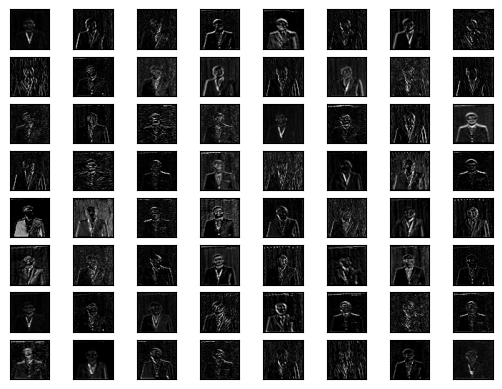

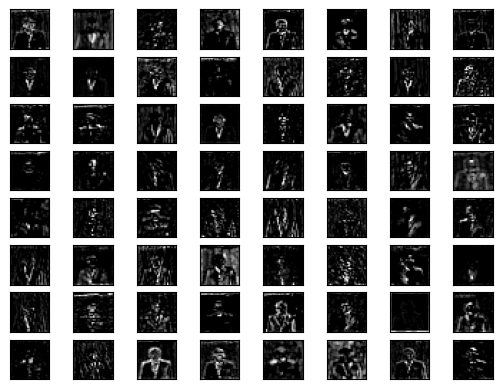

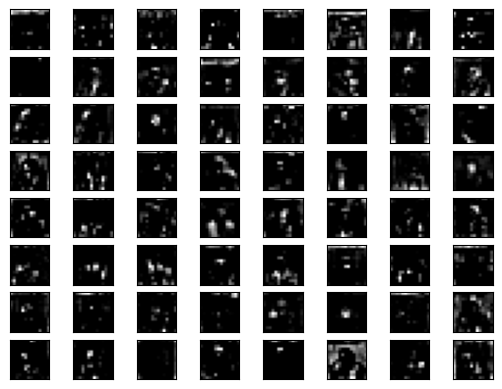

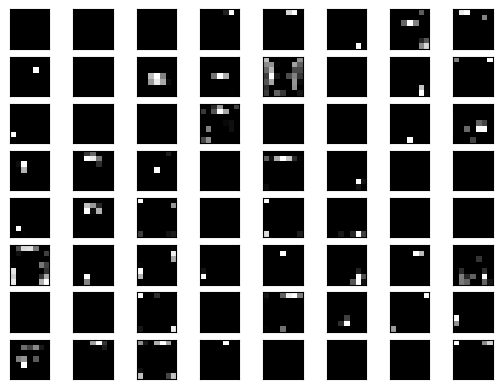

In [33]:
feature_map = model3.predict(image)

square = 8
for fmap in feature_map:
    ix = 1
    for _ in range(square):
        for _ in range(square):
            ax = pyplot.subplot(square,square,ix)
            ax.set_xticks([])
            ax.set_yticks([])
            pyplot.imshow(fmap[0,:,:,ix-1],cmap='gray')
            ix += 1
        
    pyplot.show()